# Does **BDNF** expression correlate with maze test performance?

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

print('Libraries Loaded')

Libraries Loaded


In [ ]:
data = pd.read_csv("mouse_cognition.csv")
data

,mouse_id,strain,maze_test,object_recognition,fear_conditioning,social_memory,BDNF,CREB1,DRD2,GRIN1,diet,light_hours,exercise_wheel,age_weeks,weight_g
0,M001,A,78,72,65,70,8.2,6.5,5.8,7.1,standard,12,yes,12,28.5
1,M002,A,82,75,68,73,8.5,6.8,5.6,7.4,standard,12,yes,14,29.2
2,M003,A,75,70,62,68,7.9,6.3,5.9,6.9,standard,12,no,11,27.8
3,M004,A,80,74,66,71,8.3,6.6,5.7,7.2,enriched,12,yes,13,28.1
4,M005,A,77,71,64,69,8.1,6.4,5.8,7.0,standard,12,no,12,28.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,M116,H,68,72,68,72,7.2,7.5,6.5,7.2,standard,12,no,12,26.1
116,M117,H,70,74,70,74,7.4,7.7,6.3,7.4,standard,12,yes,13,25.8
117,M118,H,66,70,66,70,7.0,7.3,6.7,7.0,high_fat,12,no,10,28.0
118,M119,H,74,78,74,78,7.8,8.1,6.0,7.8,enriched,12,yes,15,26.6


In [ ]:
data.shape
data.columns

Index(['mouse_id', 'strain', 'maze_test', 'object_recognition',
       'fear_conditioning', 'social_memory', 'BDNF', 'CREB1', 'DRD2', 'GRIN1',
       'diet', 'light_hours', 'exercise_wheel', 'age_weeks', 'weight_g'],
      dtype='object')

In [ ]:
#Quick_data_audit 
data.dtypes
data.isna().sum()


mouse_id              0
strain                0
maze_test             0
object_recognition    0
fear_conditioning     0
social_memory         0
BDNF                  0
CREB1                 0
DRD2                  0
GRIN1                 0
diet                  0
light_hours           0
exercise_wheel        0
age_weeks             0
weight_g              0
dtype: int64

In [ ]:
data[['BDNF', 'maze_test']].isna().sum()

data[['BDNF', 'maze_test']].describe()




,BDNF,maze_test
count,120.000000,120.000000
mean,7.262500,69.833333
std,1.009373,9.484471
min,5.300000,50.000000
25%,6.500000,63.000000
50%,7.200000,69.500000
75%,7.900000,76.000000
max,9.600000,91.000000


In [ ]:
data['strain'].value_counts()

strain
A    15
B    15
C    15
D    15
E    15
F    15
G    15
H    15
Name: count, dtype: int64

In [ ]:
data[['diet', 'exercise_wheel', 'light_hours']].value_counts().head(10)


diet      exercise_wheel  light_hours
standard  yes             12             25
          no              12             23
enriched  yes             12             20
high_fat  no              12             18
standard  yes             8               5
                          16              5
enriched  yes             16              4
                          8               4
          no              12              4
high_fat  no              8               3
Name: count, dtype: int64

In [ ]:
#Analysis_Data_Frame_Creation 

df = data[['mouse_id', 'strain', 'diet', 'exercise_wheel', 'light_hours', 'age_weeks', 'weight_g', 'BDNF', 'maze_test']].copy()


In [ ]:
df = df.dropna(subset=['BDNF', 'maze_test'])


In [ ]:
df.shape
df[['BDNF', 'maze_test']].describe()


,BDNF,maze_test
count,120.000000,120.000000
mean,7.262500,69.833333
std,1.009373,9.484471
min,5.300000,50.000000
25%,6.500000,63.000000
50%,7.200000,69.500000
75%,7.900000,76.000000
max,9.600000,91.000000


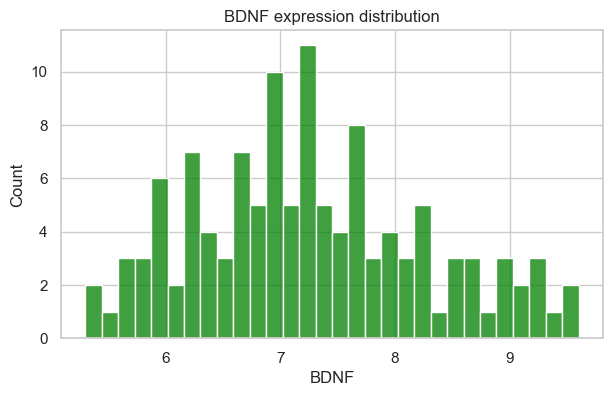

In [ ]:
#Distributions(to_better_understand_the_variables)
plt.figure(figsize=(7, 4))
sns.histplot(df['BDNF'], bins=30, color='green')
plt.title("BDNF expression distribution")
plt.xlabel("BDNF")
plt.ylabel("Count")

plt.show()


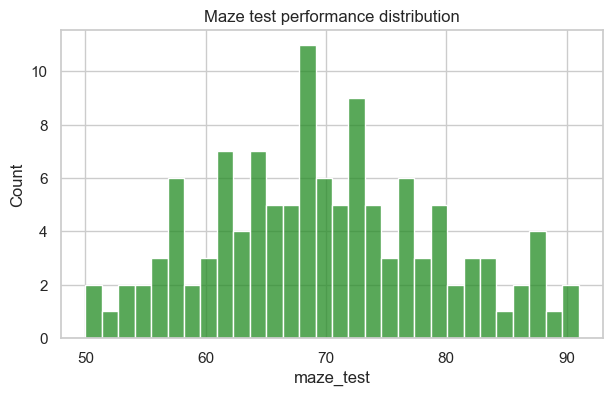

In [ ]:
plt.figure(figsize=(7, 4))
sns.histplot(df['maze_test'], bins=30,color='forestgreen')
plt.title("Maze test performance distribution")
plt.xlabel("maze_test")
plt.ylabel("Count")

plt.show()



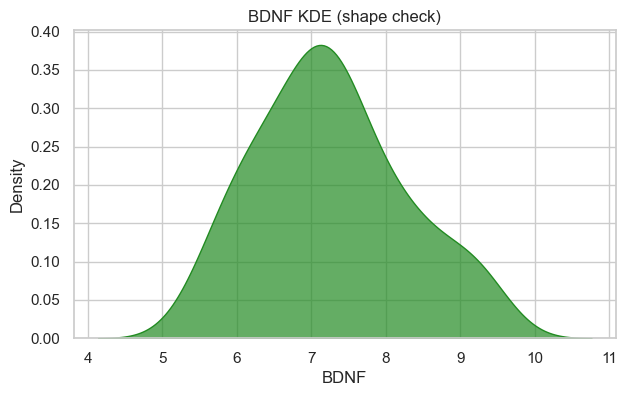

In [ ]:
plt.figure(figsize=(7, 4))
sns.kdeplot(df['BDNF'], fill=True, alpha=0.7, color='forestgreen')
plt.title("BDNF KDE (shape check)")
plt.xlabel("BDNF")
plt.show()


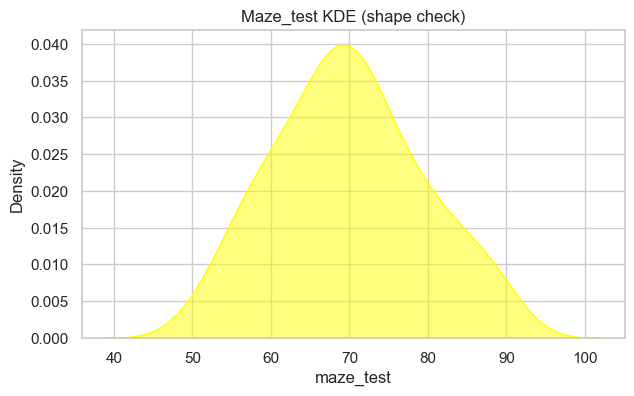

In [ ]:
plt.figure(figsize=(7, 4))
sns.kdeplot(df['maze_test'], fill=True, alpha=0.5, color='yellow')
#cause_green_is_my_color_but_I_am_not_that_biased
plt.title("Maze_test KDE (shape check)")
plt.xlabel("maze_test")
plt.show()


In [ ]:
#Correlation_Heatmap 
corr_vars = ['BDNF', 'maze_test', 'object_recognition', 'fear_conditioning', 'social_memory']
corr_df = data[corr_vars].dropna()
corr_m = corr_df.corr()


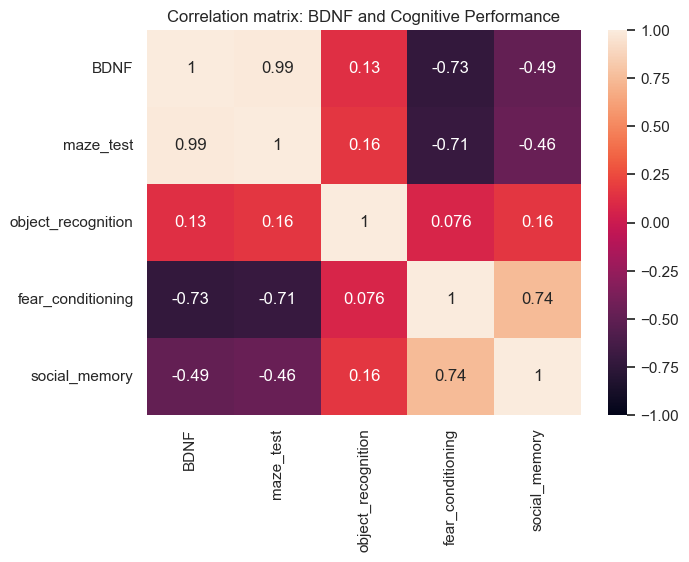

In [ ]:
plt.figure(figsize=(7, 5))
sns.heatmap(corr_m, annot=True, vmin=-1, vmax=1)
plt.title("Correlation matrix: BDNF and Cognitive Performance")
plt.show()


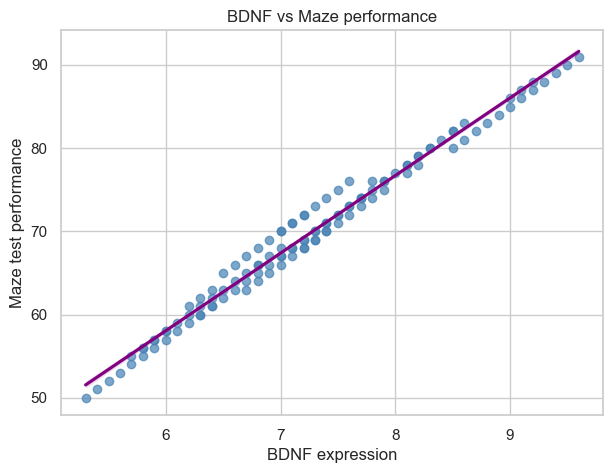

In [ ]:
#Main_Visualization 
plt.figure(figsize=(7, 5))
sns.regplot(data=df, x='BDNF', y='maze_test', scatter_kws={'alpha': 0.7,'color': 'steelblue' },line_kws={'color': 'purple'}
)
plt.title("BDNF vs Maze performance")
plt.xlabel("BDNF expression")
plt.ylabel("Maze test performance")
plt.show()


In [ ]:
#Pearson_Correlation(statistcal_test)
r_pearson, p_pearson = stats.pearsonr(df['BDNF'], df['maze_test'])
print("Pearson r:", round(r_pearson, 3))
print("Pearson p-value:", p_pearson)


Pearson r: 0.992
Pearson p-value: 1.8733829371226742e-107


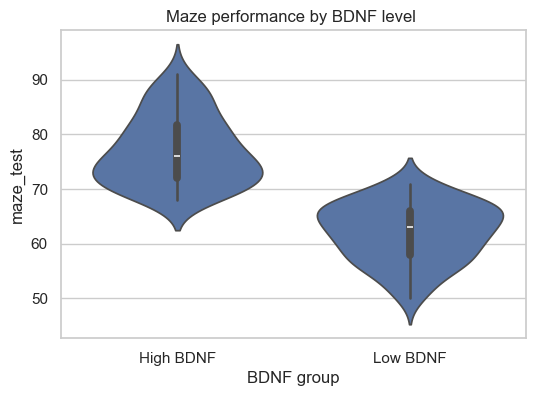

In [ ]:
#Violin_Plot(cause_all_pharmaceutical_journals_have_one)
df['BDNF_group'] = np.where(df['BDNF'] >= df['BDNF'].median(), 'High BDNF', 'Low BDNF')

plt.figure(figsize=(6, 4))
sns.violinplot(data=df, x='BDNF_group', y='maze_test')
plt.title("Maze performance by BDNF level ")
plt.xlabel("BDNF group")
plt.xlabel("BDNF group")

plt.show()



In [ ]:
#Permutation_Test(For_Correlation)
x = df['BDNF'].values
y = df['maze_test'].values

observed_r, _ = stats.pearsonr(x, y)
n_permutations = 10000
perm_rs = []

#Loop_(χωρις_βημα)

for _ in range(n_permutations):
    x_shuffled = np.random.permutation(x)
    r_perm, _ = stats.pearsonr(x_shuffled, y)
    perm_rs.append(r_perm)

perm_rs = np.array(perm_rs)
p_perm_two_sided = np.mean(np.abs(perm_rs) >= abs(observed_r))

print("Observed Pearson r:", round(observed_r, 3))
print("Permutation p-value (two-sided):", round(p_perm_two_sided, 4))


Observed Pearson r: 0.992
Permutation p-value (two-sided): 0.0


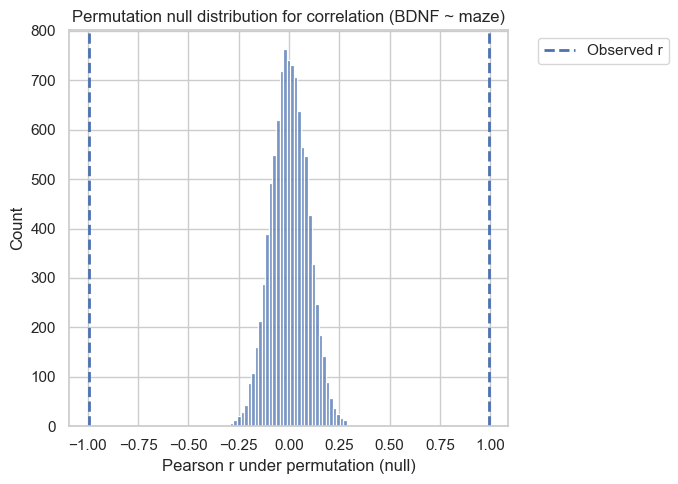

In [ ]:
#Plotting_For_the_Permutation_Test

plt.figure(figsize=(7, 5))
sns.histplot(perm_rs, bins=40)
plt.axvline(observed_r, linestyle='--', linewidth=2, label='Observed r')
plt.axvline(-observed_r, linestyle='--', linewidth=2)
plt.title("Permutation null distribution for correlation (BDNF ~ maze)")
plt.xlabel("Pearson r under permutation (null)")
plt.ylabel("Count")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') #αυτό_το_ρώτησα
plt.tight_layout() #για_μενα_το_υπομνημα_ηταν_απαραίτητο

plt.show()



In [ ]:
#Interpretation_of_the_Experiment 

direction = "positive" if r_pearson > 0 else "negative"

print(f"Interpretation: The association between BDNF expression and maze performance is {direction} (Pearson r = {round(r_pearson,3)}).")

if p_pearson < 0.05:
    print("This correlation is statistically significant by Pearson's test (p < 0.05).")
else:
    print("This correlation is not statistically significant by Pearson's test (p >= 0.05).")


Interpretation: The association between BDNF expression and maze performance is positive (Pearson r = 0.992).
This correlation is statistically significant by Pearson's test (p < 0.05).


In [ ]:
print(f"Permutation validation (two-sided): p = {round(p_perm_two_sided,4)} (robustness check without distributional assumptions).")


Permutation validation (two-sided): p = 0.0 (robustness check without distributional assumptions).


In [ ]:
#Maria's_Guide_to_the_Programming_Galaxy 
np.random.seed(42)

meaning_of_life = 42

print(f"If {meaning_of_life} is the meaning, what happens when I reach {meaning_of_life + 1}?")
print("Answer: I still run permutation tests—because biology rarely gives perfect certainty.")


If 42 is the meaning, what happens when I reach 43?
Answer: I still run permutation tests—because biology rarely gives perfect certainty.
